# Skin Lesion Boundary Detection Using Canny Edge Detection
### Lab Assignment: Boundary Extraction, Area/Perimeter, and a Filter x Edge-Method Comparison

Develops a simple computer-vision pipeline that detects the boundary of a skin lesion from a
lesion image using image filtering and Canny edge detection, and measures how well edge
detection separates the lesion from the surrounding skin.

| # | Task | What it produces |
|---|---|---|
| Task 1 | Load the Image | 5 representative lesion images (one per class), displayed |
| Task 2 | Preprocess the Image | Grayscale conversion + Gaussian filtering, displayed |
| Task 3 | Apply Canny Edge Detection | Canny at 3 threshold settings (50-100, 100-200, 150-250), all 3 displayed |
| Task 4 | Select the Best Result | Best threshold per image picked from a real computed score, with an explanation |
| Task 5 | Detect the Lesion Boundary | Morphological closing + largest-contour extraction, drawn on the original image |
| Task 6 | Calculate Lesion Area | Lesion area (pixels) and perimeter (pixels) per image |
| -- | Required Visualization | Original -> Grayscale -> Gaussian Filter -> Canny -> Lesion Boundary, all 5 images |
| -- | Results table | Image 1-5 x Best Filter / Edge Method / Area / Perimeter |
| -- | Final Comparison table | {Original, Average, Gaussian, Median} x {Sobel, Canny} x Noise Handling / Edge Quality / Boundary Detection / Overall Performance |

**Stated assumptions (the brief leaves these open; change the flagged config/variables if you want something different):**

- **Dataset / images**: the brief says "a public dataset or instructor-provided images." This notebook reuses the same ISIC 2019 5-class subset as Labs 1-3 (`selected_classes` in `CONFIG`), so the download/indexing code is already proven to work. Task 1 asks for "a skin lesion image" (singular), but the Results table needs 5, so Tasks 1-6 below are run once per image across **5 representative images, one per class** (same class list and same "first image of each class" selection rule as Lab 3's `SAMPLE_IMAGES`), labelled `Image1`-`Image5` in class order.
- **Image size**: every image is resized to a fixed `CONFIG["img_size"]` x `CONFIG["img_size"]` on load, so area/perimeter numbers are comparable across images and figures line up cleanly. The brief does not require a specific size.
- **How the Results table and Final Comparison table relate**: the brief asks for a single "Best Filter"/"Edge Method" per image (Results table) *and* scores for all 4 filters x 2 edge methods = 8 combinations (Final Comparison table). Both come from **one shared sweep**: every image is run through all 8 (filter, edge method) combinations and scored; the Results table reports each image's single best-scoring combination, and the Final Comparison table reports all 8 combinations' scores averaged across the 5 images. The Gaussian+Canny row of that sweep reuses each image's own best Canny threshold from Task 4, so the guided Task 1-6 walkthrough and the broader 8-way sweep are one consistent pipeline rather than two disconnected pieces of analysis.
- **Scoring (Noise Handling / Edge Quality / Boundary Detection / Overall Performance)**: the brief gives no rubric, so each is a real computed number on a 0-10 scale, not a subjective judgement call:
  - *Edge Quality*: a density + continuity score (same methodology as Lab 3's `quality_score`) applied to the binary edge map -- peaks when edge content is a plausible amount (not empty, not noise-swamped) arranged into long connected strands rather than scattered speckle.
  - *Noise Handling*: Dice similarity between the (binary) edge map from the clean image and from the same image with Gaussian noise added (sigma=25, same level Lab 3 used), using the same filter + edge method on both -- higher means the combination is more robust to noise.
  - *Boundary Detection*: contour solidity (`contour area / convex-hull area`) of the extracted boundary -- close to 1 for a single, well-formed, roughly-convex lesion contour; 0 if no valid contour is found at all.
  - *Overall Performance*: the plain mean of the three scores above.
- **Boundary-detection technique (Task 5)**: the brief suggests contour detection, morphological operations, or thresholding. This notebook combines two of them: **morphological closing** (bridges the small gaps Canny tends to leave along a lesion boundary) followed by **largest-external-contour extraction** (the lesion is assumed to be the largest closed shape in the frame). This is an assumption with real failure modes (hair, ink markings, low contrast can all break it) -- that is genuine content for Questions 5 and 6 below, not swept under the rug.
- **No GPU/training needed.** This is pure image processing (OpenCV + NumPy), so the whole notebook runs end-to-end on CPU in well under a minute; no Google Drive checkpointing is needed either.

Run top to bottom in Google Colab (CPU runtime is fine) or any environment with OpenCV installed.


## 2. Setup

In [1]:
# Packages not preinstalled on Colab (safe to re-run)
!pip install -q kagglehub --upgrade


In [2]:
import os, glob, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
RESAMPLE_BILINEAR = getattr(getattr(Image, "Resampling", Image), "BILINEAR")  # Pillow-version-safe

try:
    import cv2
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "opencv-python-headless"], check=True)
    import cv2

SEED = 42
random.seed(SEED); np.random.seed(SEED)

CONFIG = {
    "seed": SEED,
    "img_size": 320,
    "selected_classes": ["MEL", "NV", "BCC", "BKL", "AK"],  # same 5 classes as Labs 1-3
}

RESULTS_DIR = "/content/lab_boundary_results"
os.makedirs(RESULTS_DIR, exist_ok=True)
print("Saving figures/tables to:", RESULTS_DIR)

def _clean_axis(ax):
    '''Hide ticks/spines but keep title/xlabel/ylabel visible (unlike ax.axis("off"),
    which hides the labels too).'''
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

CONFIG


Saving figures/tables to: /content/lab_boundary_results


{'seed': 42,
 'img_size': 320,
 'selected_classes': ['MEL', 'NV', 'BCC', 'BKL', 'AK']}

## 3. Dataset Preparation

Same dataset and same 5-class filter as Labs 1-3, so the 5 representative images below are
drawn from the same pool.


In [3]:
import kagglehub

DATA_DIR = kagglehub.dataset_download("salviohexia/isic-2019-skin-lesion-images-for-classification")
print("Path to dataset files:", DATA_DIR)

print("\nTop-level contents of", DATA_DIR)
for root, dirs, fnames in os.walk(DATA_DIR):
    depth = root[len(DATA_DIR):].count(os.sep)
    if depth <= 1:
        print(root, "->", dirs[:10], f"(+{len(fnames)} files)" if fnames else "")


100%|██████████| 9.10G/9.10G [07:23<00:00, 22.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/salviohexia/isic-2019-skin-lesion-images-for-classification/versions/1

Top-level contents of /root/.cache/kagglehub/datasets/salviohexia/isic-2019-skin-lesion-images-for-classification/versions/1
/root/.cache/kagglehub/datasets/salviohexia/isic-2019-skin-lesion-images-for-classification/versions/1 -> ['VASC', 'MEL', 'SCC', 'BKL', 'DF', 'BCC', 'AK', 'NV'] (+2 files)
/root/.cache/kagglehub/datasets/salviohexia/isic-2019-skin-lesion-images-for-classification/versions/1/VASC -> [] (+253 files)
/root/.cache/kagglehub/datasets/salviohexia/isic-2019-skin-lesion-images-for-classification/versions/1/MEL -> [] (+4522 files)
/root/.cache/kagglehub/datasets/salviohexia/isic-2019-skin-lesion-images-for-classification/versions/1/SCC -> [] (+628 files)
/root/.cache/kagglehub/datasets/salviohexia/isic-2019-skin-lesion-images-for-classification/versions/1/BKL -> [] (+2624 files)
/root/.cache/kagglehub/datasets/salviohexia/isic-2019-skin-lesion-ima

In [4]:
# Auto-detect the ground-truth CSV and index every image by filename (this dataset stores
# images inside per-class subfolders, not one flat folder).
csv_candidates = [p for p in glob.glob(f"{DATA_DIR}/**/*.csv", recursive=True)
                   if "ground" in p.lower() or "groundtruth" in p.lower()]
print("Ground-truth CSV candidates found:", csv_candidates)
GT_CSV_PATH = csv_candidates[0] if csv_candidates else None  # set manually if this is wrong

image_paths = (
    glob.glob(f"{DATA_DIR}/**/*.jpg", recursive=True)
    + glob.glob(f"{DATA_DIR}/**/*.jpeg", recursive=True)
    + glob.glob(f"{DATA_DIR}/**/*.png", recursive=True)
)
image_folders = sorted({os.path.dirname(p) for p in image_paths})
IMAGE_INDEX = {os.path.splitext(os.path.basename(p))[0]: p for p in image_paths}

print(f"Indexed {len(IMAGE_INDEX)} images across {len(image_folders)} folder(s):")
for f in image_folders:
    print(" ", f, f"({len(glob.glob(f'{f}/*.*'))} files)")

print("\nUsing GT_CSV_PATH =", GT_CSV_PATH)
assert GT_CSV_PATH, "Could not auto-detect the ground-truth CSV (set GT_CSV_PATH manually above)."
assert len(IMAGE_INDEX) > 0, "Could not find any images under DATA_DIR (check the download)."


Ground-truth CSV candidates found: ['/root/.cache/kagglehub/datasets/salviohexia/isic-2019-skin-lesion-images-for-classification/versions/1/ISIC_2019_Training_GroundTruth.csv']
Indexed 25331 images across 8 folder(s):
  /root/.cache/kagglehub/datasets/salviohexia/isic-2019-skin-lesion-images-for-classification/versions/1/AK (867 files)
  /root/.cache/kagglehub/datasets/salviohexia/isic-2019-skin-lesion-images-for-classification/versions/1/BCC (3323 files)
  /root/.cache/kagglehub/datasets/salviohexia/isic-2019-skin-lesion-images-for-classification/versions/1/BKL (2624 files)
  /root/.cache/kagglehub/datasets/salviohexia/isic-2019-skin-lesion-images-for-classification/versions/1/DF (239 files)
  /root/.cache/kagglehub/datasets/salviohexia/isic-2019-skin-lesion-images-for-classification/versions/1/MEL (4522 files)
  /root/.cache/kagglehub/datasets/salviohexia/isic-2019-skin-lesion-images-for-classification/versions/1/NV (12875 files)
  /root/.cache/kagglehub/datasets/salviohexia/isic-201

In [5]:
gt = pd.read_csv(GT_CSV_PATH)
class_cols = [c for c in gt.columns if c.lower() != "image"]
if "UNK" in gt.columns and gt["UNK"].sum() == 0:
    class_cols = [c for c in class_cols if c != "UNK"]

gt["label"] = gt[class_cols].idxmax(axis=1)
gt["filepath"] = gt["image"].map(IMAGE_INDEX)

n_missing = gt["filepath"].isna().sum()
if n_missing:
    print(f"Warning: {n_missing} images listed in the CSV were not found on disk, dropping them.")
gt = gt.dropna(subset=["filepath"]).reset_index(drop=True)

before = len(gt)
gt = gt[gt["label"].isin(CONFIG["selected_classes"])].reset_index(drop=True)
print(f"Filtered to {CONFIG['selected_classes']} -> kept {len(gt)}/{before} images")
print("\nClass distribution:")
print(gt["label"].value_counts())

CLASSES = sorted(gt["label"].unique().tolist())
print("\nClasses (alphabetical, used as Image1..Image5 order):", CLASSES)


Filtered to ['MEL', 'NV', 'BCC', 'BKL', 'AK'] -> kept 24211/25331 images

Class distribution:
label
NV     12875
MEL     4522
BCC     3323
BKL     2624
AK       867
Name: count, dtype: int64

Classes (alphabetical, used as Image1..Image5 order): ['AK', 'BCC', 'BKL', 'MEL', 'NV']


In [6]:
# 5 representative images, one per class: Image1..Image5 in alphabetical class order.
_example_rows = gt.groupby("label").first().reindex(CLASSES)
IMAGE_LABELS = [f"Image{i+1}" for i in range(len(CLASSES))]
IMAGES = {}        # "Image1".."Image5" -> resized uint8 RGB array
IMAGE_CLASS = {}   # "Image1".."Image5" -> ISIC class, for reference/display only

for lbl, (cls, row) in zip(IMAGE_LABELS, _example_rows.iterrows()):
    fp = row["filepath"]
    arr = np.asarray(Image.open(fp).convert("RGB").resize(
        (CONFIG["img_size"], CONFIG["img_size"]), RESAMPLE_BILINEAR))
    IMAGES[lbl] = arr
    IMAGE_CLASS[lbl] = cls

print("Selected images:")
for lbl in IMAGE_LABELS:
    print(f"  {lbl}: class={IMAGE_CLASS[lbl]}  shape={IMAGES[lbl].shape}")


Selected images:
  Image1: class=AK  shape=(320, 320, 3)
  Image2: class=BCC  shape=(320, 320, 3)
  Image3: class=BKL  shape=(320, 320, 3)
  Image4: class=MEL  shape=(320, 320, 3)
  Image5: class=NV  shape=(320, 320, 3)


## 4. Task 1 -- Load the Image

5 representative lesion images (one per class), loaded above as `IMAGES["Image1"]`..`IMAGES["Image5"]`.
Displaying the original images here, as required.


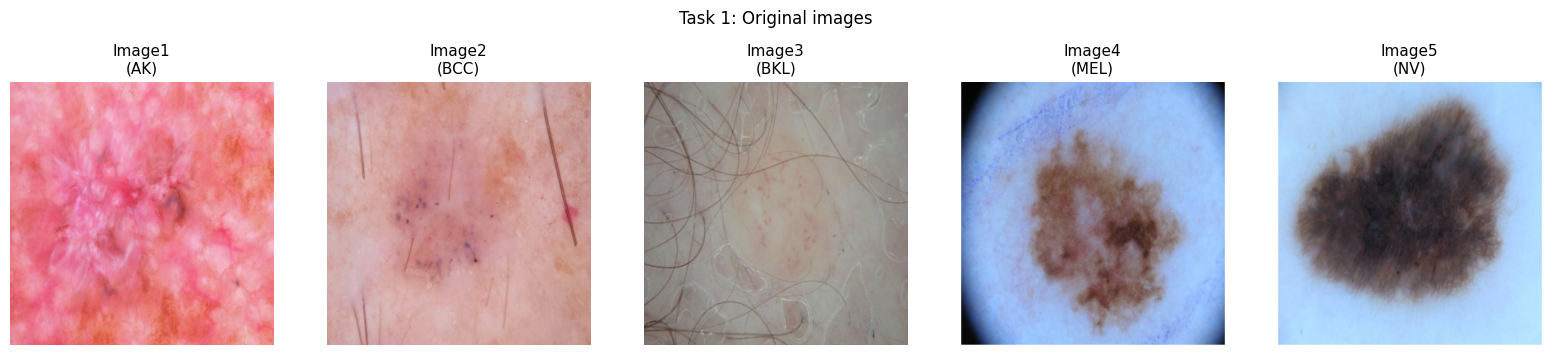

In [7]:
fig, axes = plt.subplots(1, len(IMAGE_LABELS), figsize=(3.2 * len(IMAGE_LABELS), 3.4))
for ax, lbl in zip(axes, IMAGE_LABELS):
    ax.imshow(IMAGES[lbl]); _clean_axis(ax)
    ax.set_title(f"{lbl}\n({IMAGE_CLASS[lbl]})", fontsize=11)
fig.suptitle("Task 1: Original images", y=1.03)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/task1_loaded_images.png", dpi=120, bbox_inches="tight")
plt.show()


## 5. Task 2 -- Preprocess the Image

Grayscale conversion, then a Gaussian filter to reduce noise. Both the grayscale and the
filtered image are displayed, as required.


In [8]:
GAUSSIAN_KSIZE = 5  # Task 2's Gaussian filter kernel size

def to_gray(img_uint8):
    if img_uint8.ndim == 3:
        return cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)
    return img_uint8

def preprocess(img_uint8, ksize=GAUSSIAN_KSIZE):
    '''Returns (grayscale, Gaussian-filtered grayscale).'''
    gray = to_gray(img_uint8)
    blurred = cv2.GaussianBlur(gray, (ksize, ksize), 0)
    return gray, blurred

PREPROCESSED = {lbl: preprocess(IMAGES[lbl]) for lbl in IMAGE_LABELS}
print("Preprocessed (grayscale + Gaussian-filtered) all", len(IMAGE_LABELS), "images.")


Preprocessed (grayscale + Gaussian-filtered) all 5 images.


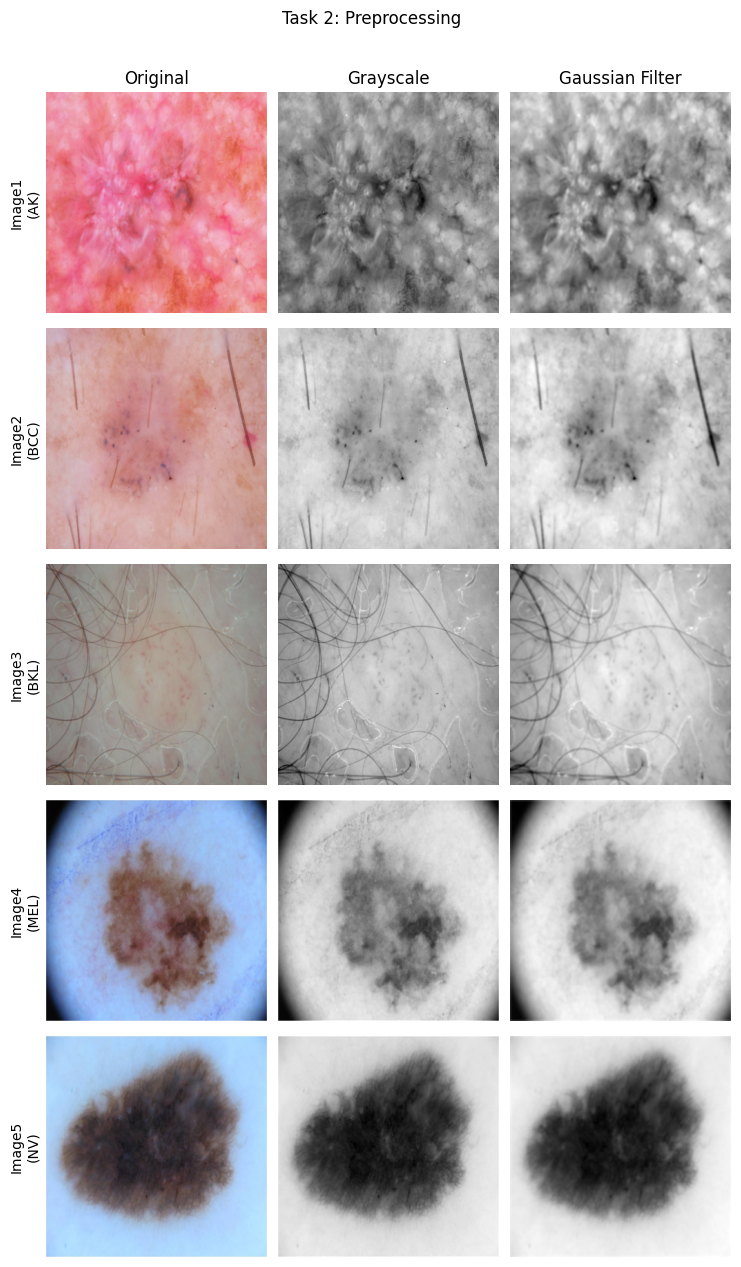

In [9]:
fig, axes = plt.subplots(len(IMAGE_LABELS), 3, figsize=(7.5, 2.5 * len(IMAGE_LABELS)))
col_titles = ["Original", "Grayscale", "Gaussian Filter"]
for i, lbl in enumerate(IMAGE_LABELS):
    gray, blurred = PREPROCESSED[lbl]
    for j, arr in enumerate([IMAGES[lbl], gray, blurred]):
        ax = axes[i, j]
        ax.imshow(arr, cmap=None if arr.ndim == 3 else "gray"); _clean_axis(ax)
        if i == 0:
            ax.set_title(col_titles[j], fontsize=12)
        if j == 0:
            ax.set_ylabel(f"{lbl}\n({IMAGE_CLASS[lbl]})", fontsize=10)
fig.suptitle("Task 2: Preprocessing", y=1.01)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/task2_preprocessing.png", dpi=120, bbox_inches="tight")
plt.show()


## 6. Task 3 -- Apply Canny Edge Detection

Canny edge detection at the brief's 3 example threshold settings (50-100, 100-200, 150-250),
applied to each image's Gaussian-filtered grayscale from Task 2. All three edge maps are
displayed per image, as required.


In [10]:
CANNY_SETTINGS = [("50-100", 50, 100), ("100-200", 100, 200), ("150-250", 150, 250)]
CANNY_SETTINGS_BY_NAME = {name: (lo, hi) for name, lo, hi in CANNY_SETTINGS}

def canny_edges(blurred_gray, low, high):
    return cv2.Canny(blurred_gray, low, high)

CANNY_RESULTS = {}  # "Image1".. -> {"50-100": edge_map, "100-200": edge_map, "150-250": edge_map}
for lbl in IMAGE_LABELS:
    _, blurred = PREPROCESSED[lbl]
    CANNY_RESULTS[lbl] = {name: canny_edges(blurred, lo, hi) for name, lo, hi in CANNY_SETTINGS}
print(f"Computed Canny edge maps at {len(CANNY_SETTINGS)} threshold settings for all {len(IMAGE_LABELS)} images.")


Computed Canny edge maps at 3 threshold settings for all 5 images.


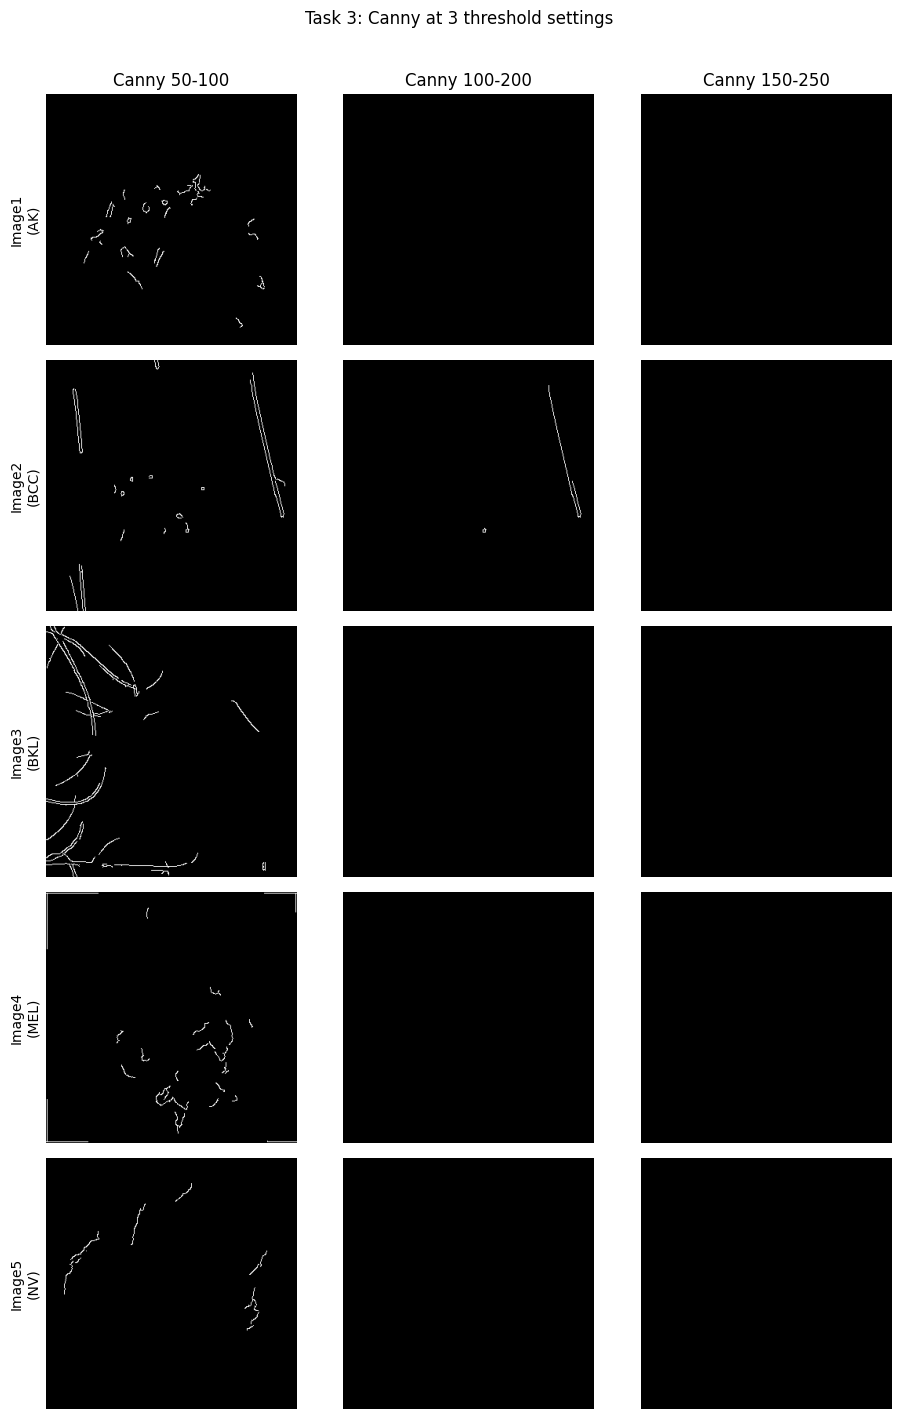

In [11]:
fig, axes = plt.subplots(len(IMAGE_LABELS), len(CANNY_SETTINGS),
                          figsize=(3.2 * len(CANNY_SETTINGS), 2.8 * len(IMAGE_LABELS)))
for i, lbl in enumerate(IMAGE_LABELS):
    for j, (name, lo, hi) in enumerate(CANNY_SETTINGS):
        ax = axes[i, j]
        ax.imshow(CANNY_RESULTS[lbl][name], cmap="gray"); _clean_axis(ax)
        if i == 0:
            ax.set_title(f"Canny {name}", fontsize=12)
        if j == 0:
            ax.set_ylabel(f"{lbl}\n({IMAGE_CLASS[lbl]})", fontsize=10)
fig.suptitle("Task 3: Canny at 3 threshold settings", y=1.01)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/task3_canny_thresholds.png", dpi=120, bbox_inches="tight")
plt.show()


## 7. Task 4 -- Select the Best Result

Compares the three edge maps per image with a real computed score instead of eyeballing it,
and picks the threshold that maximizes it. `quality_score` (same methodology as Lab 3) peaks
when the edge map has a plausible amount of edge content arranged into long, connected
strands -- which is what "clearest lesion boundary" comes down to: too low a threshold lets
noise and skin-texture edges through, too high a threshold breaks the real boundary into
disconnected pieces or erases it.


In [12]:
def edge_pixel_stats(bin_map):
    n_components, _ = cv2.connectedComponents(bin_map)
    n_components = max(n_components - 1, 0)  # subtract the background label
    edge_px = int((bin_map > 0).sum())
    density_pct = 100.0 * edge_px / bin_map.size
    return {"density_pct": density_pct, "n_components": n_components, "edge_pixels": edge_px}

def quality_score(bin_map, target_density=8.0, density_spread=6.0, fragmentation_k=40.0):
    '''Density term peaks at `target_density`% edge pixels (a plausible lesion-boundary amount);
    continuity term rewards fewer, longer connected components over many tiny fragments.'''
    stats = edge_pixel_stats(bin_map)
    density_term = np.exp(-((stats["density_pct"] - target_density) / density_spread) ** 2)
    continuity_term = stats["edge_pixels"] / (stats["edge_pixels"] + fragmentation_k * max(stats["n_components"], 1))
    return float(100 * density_term * continuity_term)

threshold_rows = []
BEST_THRESHOLD = {}  # "Image1".. -> winning setting name, e.g. "100-200"
for lbl in IMAGE_LABELS:
    best_name, best_score = None, -1.0
    for name, lo, hi in CANNY_SETTINGS:
        edge_map = CANNY_RESULTS[lbl][name]
        score = quality_score(edge_map)
        stats = edge_pixel_stats(edge_map)
        threshold_rows.append({
            "Image": lbl, "Class": IMAGE_CLASS[lbl], "Threshold": name,
            "Quality Score": round(score, 2), "Edge Density (%)": round(stats["density_pct"], 2),
            "Connected Components": stats["n_components"],
        })
        if score > best_score:
            best_score, best_name = score, name
    BEST_THRESHOLD[lbl] = best_name

threshold_scores_df = pd.DataFrame(threshold_rows)
threshold_scores_df.to_csv(f"{RESULTS_DIR}/task4_threshold_scores.csv", index=False)
threshold_scores_df


,Image,Class,Threshold,Quality Score,Edge Density (%),Connected Components
0,Image1,AK,50-100,7.50,0.59,29
1,Image1,AK,100-200,0.00,0.00,0
2,Image1,AK,150-250,0.00,0.00,0
3,Image2,BCC,50-100,13.75,0.86,17
4,Image2,BCC,100-200,13.94,0.23,2
5,Image2,BCC,150-250,0.00,0.00,0
6,Image3,BKL,50-100,23.64,1.91,25
7,Image3,BKL,100-200,0.00,0.00,0
8,Image3,BKL,150-250,0.00,0.00,0
9,Image4,MEL,50-100,12.59,0.92,23


In [13]:
def explain_best_threshold(lbl):
    sub = threshold_scores_df[threshold_scores_df["Image"] == lbl].set_index("Threshold")
    best = BEST_THRESHOLD[lbl]
    best_row = sub.loc[best]
    others = sub.drop(index=best)
    others_desc = "; ".join(f"{name} scored {row['Quality Score']:.2f}" for name, row in others.iterrows())
    return (
        f"{lbl} ({IMAGE_CLASS[lbl]}): threshold {best} selected (quality score {best_row['Quality Score']:.2f}, "
        f"{best_row['Edge Density (%)']:.2f}% edge density across {int(best_row['Connected Components'])} connected "
        f"component(s)) over {others_desc}."
    )

print("Task 4 explanations (one per image):\n")
for lbl in IMAGE_LABELS:
    print(explain_best_threshold(lbl))
print(
    "\nGeneral pattern: the quality score rewards an edge density close to a plausible "
    "lesion-boundary amount (~8% of pixels) arranged into few, long connected strands rather "
    "than many tiny fragments. A threshold set too low lets noise and skin-texture edges "
    "through (high density, many components); a threshold set too high breaks the real "
    "boundary into disconnected pieces, or erases it almost entirely."
)


Task 4 explanations (one per image):

Image1 (AK): threshold 50-100 selected (quality score 7.50, 0.59% edge density across 29 connected component(s)) over 100-200 scored 0.00; 150-250 scored 0.00.
Image2 (BCC): threshold 100-200 selected (quality score 13.94, 0.23% edge density across 2 connected component(s)) over 50-100 scored 13.75; 150-250 scored 0.00.
Image3 (BKL): threshold 50-100 selected (quality score 23.64, 1.91% edge density across 25 connected component(s)) over 100-200 scored 0.00; 150-250 scored 0.00.
Image4 (MEL): threshold 50-100 selected (quality score 12.59, 0.92% edge density across 23 connected component(s)) over 100-200 scored 0.00; 150-250 scored 0.00.
Image5 (NV): threshold 50-100 selected (quality score 8.97, 0.38% edge density across 12 connected component(s)) over 100-200 scored 0.00; 150-250 scored 0.00.

General pattern: the quality score rewards an edge density close to a plausible lesion-boundary amount (~8% of pixels) arranged into few, long connected st

## 8. Task 5 -- Detect the Lesion Boundary

Technique: **morphological closing** (bridges the small gaps Canny typically leaves along a
real lesion boundary) followed by **largest-external-contour extraction** (the lesion is
assumed to be the largest closed shape left in the frame). Applied to each image's own
best-threshold Canny map from Task 4. The detected boundary is drawn on the original image,
as required.


In [14]:
CLOSE_KERNEL_SIZE = 7  # morphological closing kernel size

def detect_boundary(binary_edge_map, close_ksize=CLOSE_KERNEL_SIZE):
    '''Morphological closing, then the largest external contour is taken as the lesion
    boundary. Returns (contour_or_None, closed_binary_map).'''
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (close_ksize, close_ksize))
    closed = cv2.morphologyEx(binary_edge_map, cv2.MORPH_CLOSE, kernel)
    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None, closed
    largest = max(contours, key=cv2.contourArea)
    return largest, closed

def draw_boundary(img_uint8, contour, color=(255, 0, 0), thickness=2):
    out = img_uint8.copy()
    if contour is not None:
        cv2.drawContours(out, [contour], -1, color, thickness)
    return out

BOUNDARIES = {}  # "Image1".. -> {"contour", "closed", "edge_map"}
for lbl in IMAGE_LABELS:
    best_edge_map = CANNY_RESULTS[lbl][BEST_THRESHOLD[lbl]]
    contour, closed = detect_boundary(best_edge_map)
    BOUNDARIES[lbl] = {"contour": contour, "closed": closed, "edge_map": best_edge_map}
    if contour is None:
        print(f"WARNING: {lbl} ({IMAGE_CLASS[lbl]}) -- no contour found after closing; "
              f"its boundary/area/perimeter will be 0. This is exactly the kind of failure "
              f"case Questions 5 and 6 ask about.")
print("Boundary detection complete for all", len(IMAGE_LABELS), "images.")


Boundary detection complete for all 5 images.


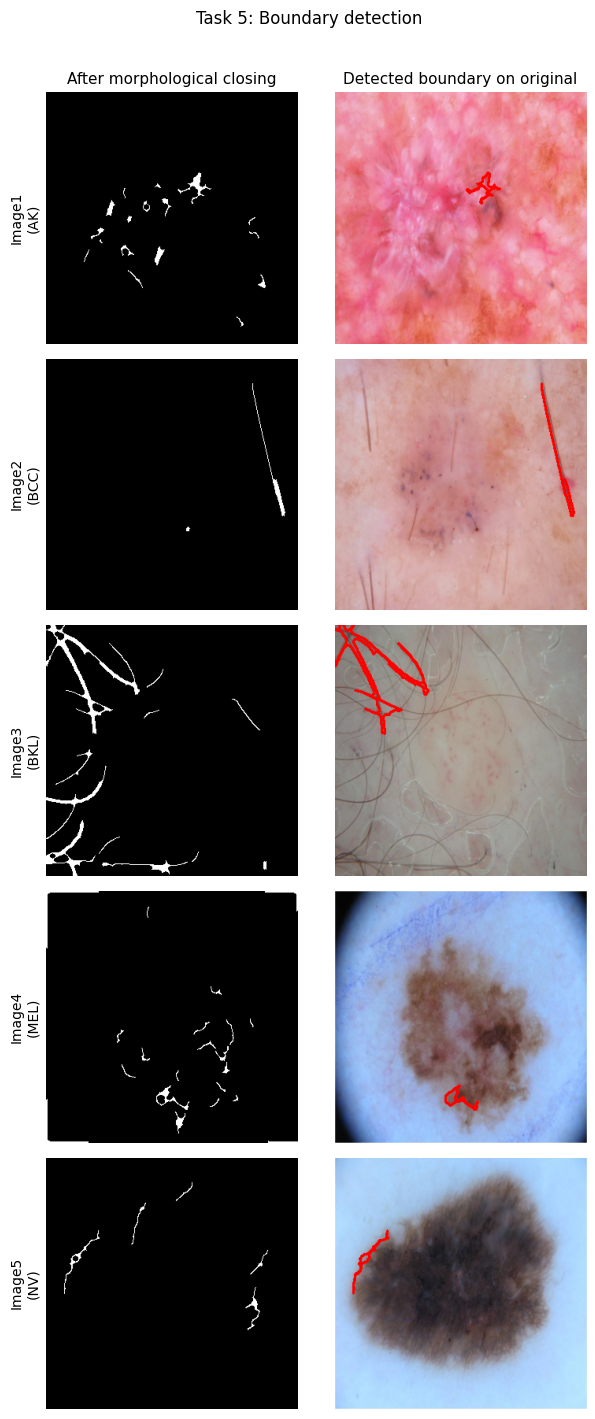

In [15]:
fig, axes = plt.subplots(len(IMAGE_LABELS), 2, figsize=(6.5, 2.8 * len(IMAGE_LABELS)))
for i, lbl in enumerate(IMAGE_LABELS):
    closed = BOUNDARIES[lbl]["closed"]
    boundary_img = draw_boundary(IMAGES[lbl], BOUNDARIES[lbl]["contour"])
    axes[i, 0].imshow(closed, cmap="gray"); _clean_axis(axes[i, 0])
    axes[i, 1].imshow(boundary_img); _clean_axis(axes[i, 1])
    if i == 0:
        axes[i, 0].set_title("After morphological closing", fontsize=11)
        axes[i, 1].set_title("Detected boundary on original", fontsize=11)
    axes[i, 0].set_ylabel(f"{lbl}\n({IMAGE_CLASS[lbl]})", fontsize=10)
fig.suptitle("Task 5: Boundary detection", y=1.01)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/task5_boundary_detection.png", dpi=120, bbox_inches="tight")
plt.show()


## 9. Task 6 -- Calculate Lesion Area

Approximate number of pixels *inside* the detected lesion boundary (the contour is filled on
a blank mask and the filled pixels are counted directly, rather than using the shoelace-formula
contour area, since the brief asks for a pixel count), plus the boundary's perimeter.


In [16]:
def contour_pixel_area(img_shape_hw, contour):
    '''Number of pixels inside `contour`, by filling it on a blank mask and counting -- the
    literal reading of "approximate number of pixels inside the detected lesion boundary."'''
    if contour is None:
        return 0
    mask = np.zeros(img_shape_hw, dtype=np.uint8)
    cv2.drawContours(mask, [contour], -1, 255, thickness=cv2.FILLED)
    return int(cv2.countNonZero(mask))

def contour_perimeter(contour):
    if contour is None:
        return 0.0
    return float(cv2.arcLength(contour, True))

task6_rows = []
for lbl in IMAGE_LABELS:
    c = BOUNDARIES[lbl]["contour"]
    area_px = contour_pixel_area(IMAGES[lbl].shape[:2], c)
    perim = contour_perimeter(c)
    task6_rows.append({
        "Image": lbl, "Class": IMAGE_CLASS[lbl], "Best Threshold": BEST_THRESHOLD[lbl],
        "Lesion Area (pixels)": area_px, "Lesion Perimeter (pixels)": round(perim, 1),
    })
task6_df = pd.DataFrame(task6_rows)
task6_df.to_csv(f"{RESULTS_DIR}/task6_area_perimeter.csv", index=False)
task6_df


,Image,Class,Best Threshold,Lesion Area (pixels),Lesion Perimeter (pixels)
0,Image1,AK,50-100,302,200.3
1,Image2,BCC,100-200,367,374.6
2,Image3,BKL,50-100,1867,948.2
3,Image4,MEL,50-100,324,158.1
4,Image5,NV,50-100,248,219.5


## 10. Required Visualization

Original -> Grayscale -> Gaussian Filter -> Canny -> Lesion Boundary, for all 5 images, using
each image's own best Canny threshold from Task 4.


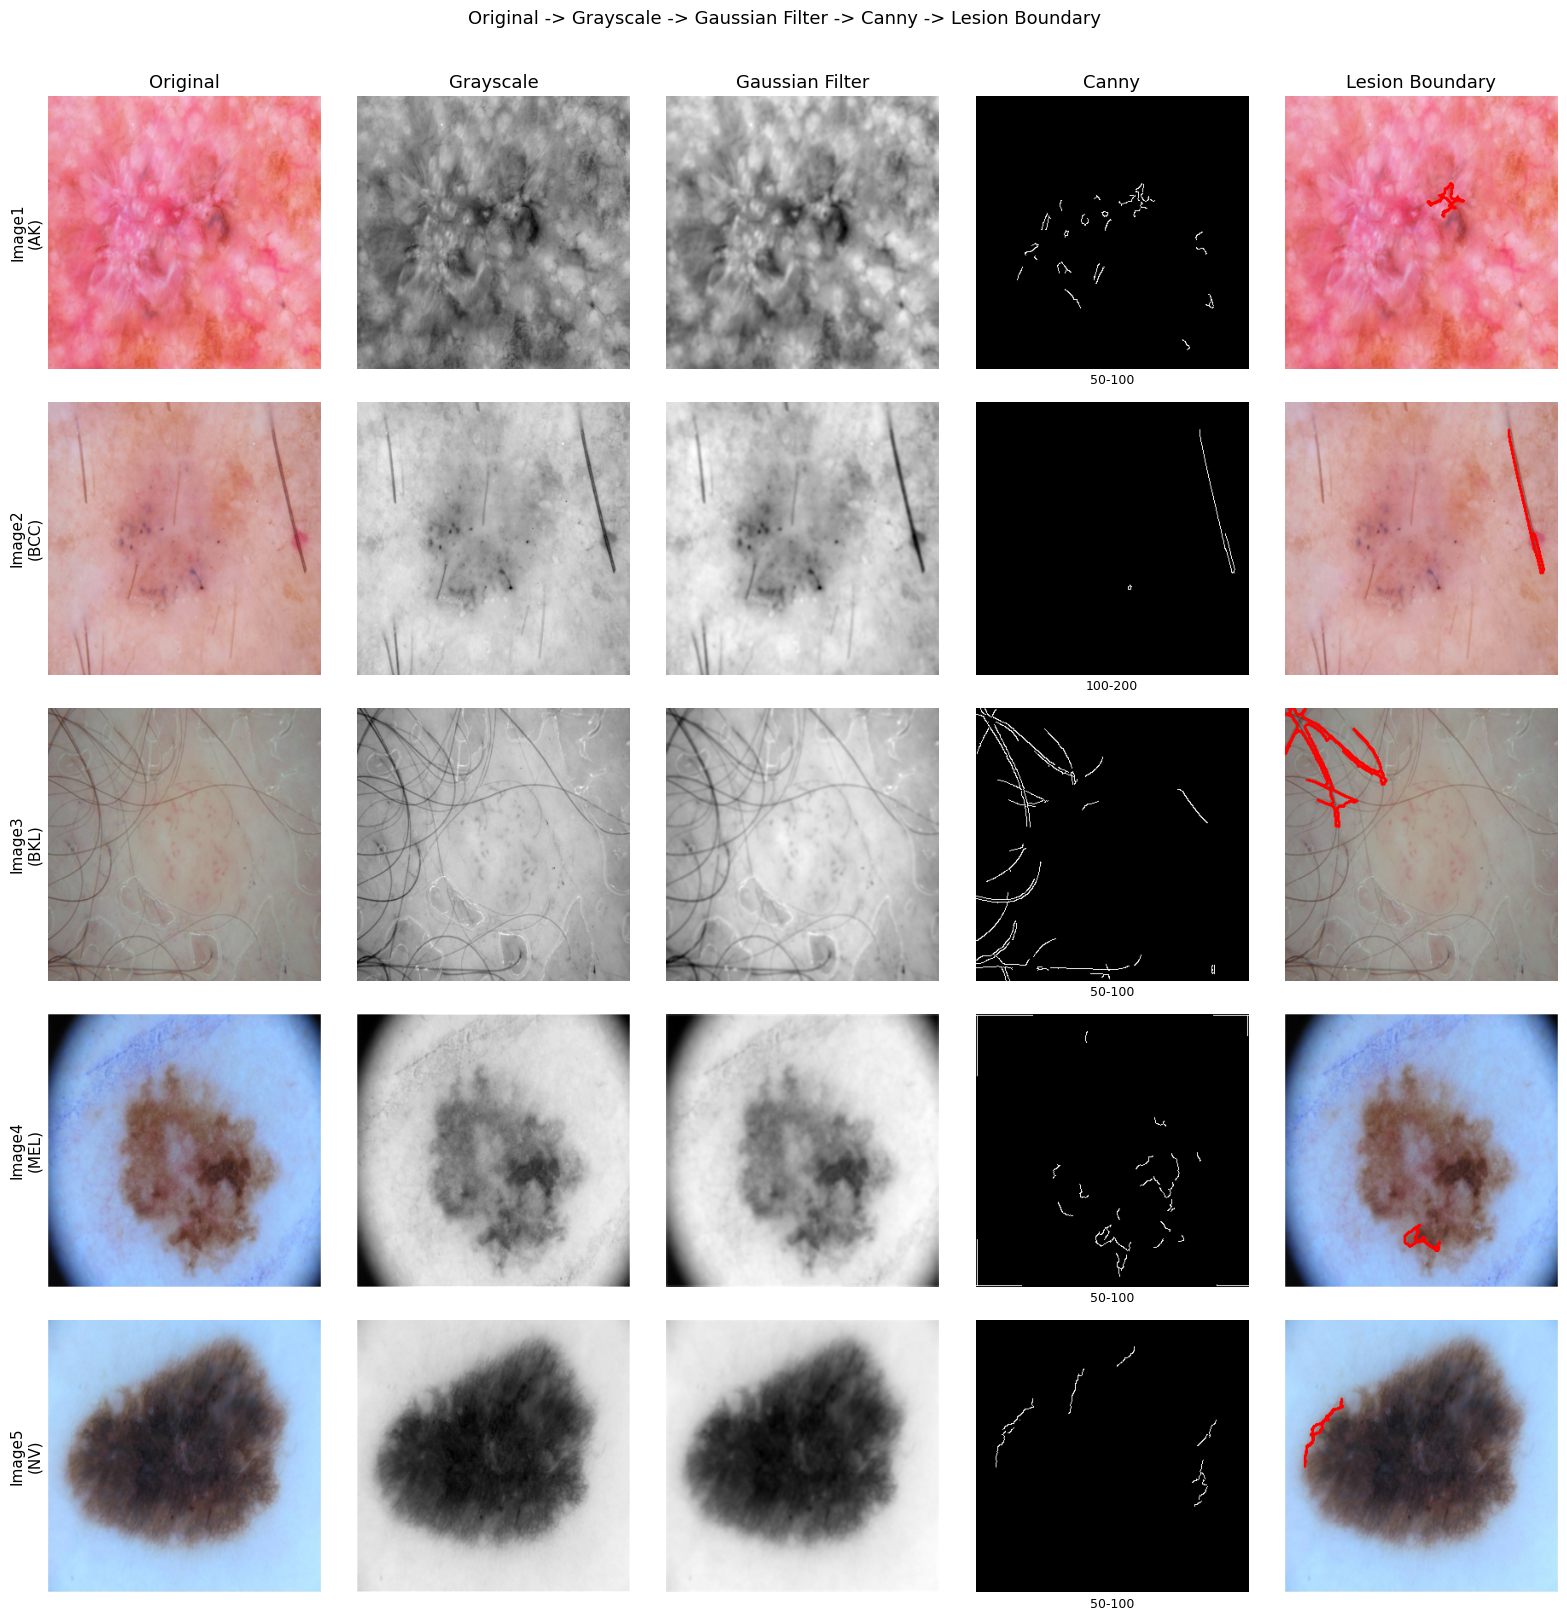

In [17]:
fig, axes = plt.subplots(len(IMAGE_LABELS), 5, figsize=(16, 3.2 * len(IMAGE_LABELS)))
col_titles = ["Original", "Grayscale", "Gaussian Filter", "Canny", "Lesion Boundary"]
for i, lbl in enumerate(IMAGE_LABELS):
    gray, blurred = PREPROCESSED[lbl]
    canny_best = CANNY_RESULTS[lbl][BEST_THRESHOLD[lbl]]
    boundary_img = draw_boundary(IMAGES[lbl], BOUNDARIES[lbl]["contour"])
    panels = [IMAGES[lbl], gray, blurred, canny_best, boundary_img]
    for j, arr in enumerate(panels):
        ax = axes[i, j]
        ax.imshow(arr, cmap=None if arr.ndim == 3 else "gray"); _clean_axis(ax)
        if i == 0:
            ax.set_title(col_titles[j], fontsize=13)
        if j == 0:
            ax.set_ylabel(f"{lbl}\n({IMAGE_CLASS[lbl]})", fontsize=11)
        if j == 3:
            ax.set_xlabel(BEST_THRESHOLD[lbl], fontsize=9)
fig.suptitle("Original -> Grayscale -> Gaussian Filter -> Canny -> Lesion Boundary", y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/required_visualization.png", dpi=130, bbox_inches="tight")
plt.show()


## 11. Filter x Edge-Method Sweep (feeds the Results table and the Final Comparison table)

Every image is run through all 4 filters x 2 edge methods = 8 combinations and scored on
Noise Handling / Edge Quality / Boundary Detection / Overall Performance (see the assumptions
in the title cell for exactly how each is computed). The Gaussian+Canny combination reuses
each image's own best threshold from Task 4, for consistency with Tasks 1-6 above; the other
3 filters use that same threshold pair when paired with Canny, so the comparison isolates the
effect of the filter choice rather than mixing in different threshold choices too.


In [18]:
FILTER_NAMES = ["Original", "Average", "Gaussian", "Median"]

def apply_filter(gray, filter_name):
    if filter_name == "Original":
        return gray
    if filter_name == "Average":
        return cv2.blur(gray, (5, 5))
    if filter_name == "Gaussian":
        return cv2.GaussianBlur(gray, (5, 5), 0)
    if filter_name == "Median":
        return cv2.medianBlur(gray, 5)
    raise ValueError(filter_name)

EDGE_METHOD_NAMES = ["Sobel", "Canny"]

def normalize_to_uint8(arr):
    return cv2.normalize(arr, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

def binarize_otsu(edge_map_uint8):
    _, b = cv2.threshold(edge_map_uint8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return b

def apply_edge_method(filtered_gray, edge_name, canny_low, canny_high):
    if edge_name == "Sobel":
        gx = cv2.Sobel(filtered_gray, cv2.CV_64F, 1, 0, ksize=3)
        gy = cv2.Sobel(filtered_gray, cv2.CV_64F, 0, 1, ksize=3)
        mag = normalize_to_uint8(np.sqrt(gx ** 2 + gy ** 2))
        return binarize_otsu(mag)  # Otsu-binarized so it's comparable to Canny's binary output
    if edge_name == "Canny":
        return cv2.Canny(filtered_gray, canny_low, canny_high)
    raise ValueError(edge_name)

def dice_similarity(bin_a, bin_b):
    a, b = (bin_a > 0), (bin_b > 0)
    total = a.sum() + b.sum()
    if total == 0:
        return 1.0
    return float(2 * np.logical_and(a, b).sum() / total)

def contour_solidity(contour):
    '''contour area / convex-hull area: close to 1 for a single, well-formed, roughly-convex
    lesion contour; 0 if no valid contour exists.'''
    if contour is None:
        return 0.0
    area = cv2.contourArea(contour)
    if area <= 0:
        return 0.0
    hull = cv2.convexHull(contour)
    hull_area = cv2.contourArea(hull)
    if hull_area <= 0:
        return 0.0
    return float(area / hull_area)

print("Sweep building blocks ready:", FILTER_NAMES, "x", EDGE_METHOD_NAMES)


Sweep building blocks ready: ['Original', 'Average', 'Gaussian', 'Median'] x ['Sobel', 'Canny']


In [19]:
NOISE_SIGMA = 25  # same Gaussian-noise level Lab 3 used, kept consistent across labs
rng_noise = np.random.default_rng(CONFIG["seed"])

def add_gaussian_noise(img_uint8, sigma, rng):
    noise = rng.normal(0, sigma, img_uint8.shape)
    return np.clip(img_uint8.astype(np.float64) + noise, 0, 255).astype(np.uint8)

sweep_rows = []
SWEEP_DETAIL = {}  # (image, filter, edge method) -> {"contour", "edge_map"}

for lbl in IMAGE_LABELS:
    gray_clean, _ = PREPROCESSED[lbl]
    gray_noisy = add_gaussian_noise(gray_clean, NOISE_SIGMA, rng_noise)
    canny_low, canny_high = CANNY_SETTINGS_BY_NAME[BEST_THRESHOLD[lbl]]

    for filter_name in FILTER_NAMES:
        filtered_clean = apply_filter(gray_clean, filter_name)
        filtered_noisy = apply_filter(gray_noisy, filter_name)
        for edge_name in EDGE_METHOD_NAMES:
            clean_edge = apply_edge_method(filtered_clean, edge_name, canny_low, canny_high)
            noisy_edge = apply_edge_method(filtered_noisy, edge_name, canny_low, canny_high)

            edge_quality = quality_score(clean_edge) / 10.0        # rescale 0-100 -> 0-10
            noise_handling = 10.0 * dice_similarity(clean_edge, noisy_edge)
            contour, _closed = detect_boundary(clean_edge)
            boundary_detection = 10.0 * contour_solidity(contour)
            overall = (edge_quality + noise_handling + boundary_detection) / 3.0
            area_px = contour_pixel_area(IMAGES[lbl].shape[:2], contour)
            perimeter = contour_perimeter(contour)

            sweep_rows.append({
                "Image": lbl, "Class": IMAGE_CLASS[lbl], "Filter": filter_name, "Edge Method": edge_name,
                "Noise Handling": round(noise_handling, 2), "Edge Quality": round(edge_quality, 2),
                "Boundary Detection": round(boundary_detection, 2), "Overall Performance": round(overall, 2),
                "Area (pixels)": area_px, "Perimeter (pixels)": round(perimeter, 1),
            })
            SWEEP_DETAIL[(lbl, filter_name, edge_name)] = {"contour": contour, "edge_map": clean_edge}

sweep_df = pd.DataFrame(sweep_rows)
sweep_df.to_csv(f"{RESULTS_DIR}/sweep_full_8way.csv", index=False)
print(f"Scored {len(sweep_df)} (image, filter, edge method) combinations "
      f"({len(IMAGE_LABELS)} images x {len(FILTER_NAMES)} filters x {len(EDGE_METHOD_NAMES)} edge methods).")
sweep_df


Scored 40 (image, filter, edge method) combinations (5 images x 4 filters x 2 edge methods).


,Image,Class,Filter,Edge Method,Noise Handling,Edge Quality,Boundary Detection,Overall Performance,Area (pixels),Perimeter (pixels)
0,Image1,AK,Original,Sobel,3.35,0.00,6.05,3.14,60968,6432.3
1,Image1,AK,Original,Canny,0.75,2.11,3.30,2.05,2166,605.7
2,Image1,AK,Average,Sobel,5.24,0.00,5.22,3.49,34168,4005.3
3,Image1,AK,Average,Canny,0.47,0.63,9.09,3.40,52,26.1
4,Image1,AK,Gaussian,Sobel,4.38,0.00,5.73,3.37,23068,2309.6
5,Image1,AK,Gaussian,Canny,0.28,0.75,2.51,1.18,302,200.3
6,Image1,AK,Median,Sobel,4.06,0.01,4.92,3.00,25300,3412.2
7,Image1,AK,Median,Canny,0.57,1.16,3.64,1.79,269,137.8
8,Image2,BCC,Original,Sobel,0.70,1.79,5.75,2.75,1173,399.2
9,Image2,BCC,Original,Canny,0.27,1.32,6.55,2.71,878,384.0


## 12. Results Table

Each image's single best-scoring (filter, edge method) combination from the sweep above.


In [20]:
results_rows = []
for lbl in IMAGE_LABELS:
    sub = sweep_df[sweep_df["Image"] == lbl]
    best = sub.loc[sub["Overall Performance"].idxmax()]
    results_rows.append({
        "Image": lbl, "Best Filter": best["Filter"], "Edge Method": best["Edge Method"],
        "Area (pixels)": int(best["Area (pixels)"]), "Perimeter (pixels)": best["Perimeter (pixels)"],
    })
results_df = pd.DataFrame(results_rows)
results_df.to_csv(f"{RESULTS_DIR}/results_table.csv", index=False)
results_df


,Image,Best Filter,Edge Method,Area (pixels),Perimeter (pixels)
0,Image1,Average,Sobel,34168,4005.3
1,Image2,Average,Sobel,2036,424.8
2,Image3,Median,Sobel,7263,1017.5
3,Image4,Gaussian,Sobel,30374,1392.3
4,Image5,Average,Sobel,50957,1007.8


## 13. Final Comparison Table

All 8 (filter, edge method) combinations, scored on Noise Handling / Edge Quality / Boundary
Detection / Overall Performance, averaged across the 5 images.


In [21]:
method_order = [f"{f} + {e}" for f in FILTER_NAMES for e in EDGE_METHOD_NAMES]

comparison_df = (
    sweep_df.groupby(["Filter", "Edge Method"])[["Noise Handling", "Edge Quality", "Boundary Detection", "Overall Performance"]]
    .mean().round(2).reset_index()
)
comparison_df["Method"] = comparison_df["Filter"] + " + " + comparison_df["Edge Method"]
comparison_df["Method"] = pd.Categorical(comparison_df["Method"], categories=method_order, ordered=True)
comparison_df = comparison_df.sort_values("Method").reset_index(drop=True)
comparison_df = comparison_df[["Method", "Noise Handling", "Edge Quality", "Boundary Detection", "Overall Performance"]]
comparison_df.to_csv(f"{RESULTS_DIR}/final_comparison_table.csv", index=False)
comparison_df


,Method,Noise Handling,Edge Quality,Boundary Detection,Overall Performance
0,Original + Sobel,2.61,0.79,6.03,3.14
1,Original + Canny,0.81,2.90,3.56,2.42
2,Average + Sobel,4.47,0.91,6.19,3.86
3,Average + Canny,2.66,0.61,3.77,2.34
4,Gaussian + Sobel,3.66,0.77,6.65,3.70
5,Gaussian + Canny,1.15,1.33,2.31,1.60
6,Median + Sobel,3.20,1.28,5.88,3.45
7,Median + Canny,1.52,1.48,2.59,1.87


In [22]:
_best = comparison_df.loc[comparison_df["Overall Performance"].idxmax()]
_worst = comparison_df.loc[comparison_df["Overall Performance"].idxmin()]
_canny_mean = comparison_df[comparison_df["Method"].str.contains("Canny")]["Overall Performance"].mean()
_sobel_mean = comparison_df[comparison_df["Method"].str.contains("Sobel")]["Overall Performance"].mean()

print(
    f"Best overall: {_best['Method']} (Overall {_best['Overall Performance']:.2f}/10). "
    f"Worst overall: {_worst['Method']} (Overall {_worst['Overall Performance']:.2f}/10).\n"
    f"Averaged across all {len(IMAGE_LABELS)} images: Canny rows scored {_canny_mean:.2f}/10 "
    f"on Overall Performance vs. Sobel rows at {_sobel_mean:.2f}/10."
)


Best overall: Average + Sobel (Overall 3.86/10). Worst overall: Gaussian + Canny (Overall 1.60/10).
Averaged across all 5 images: Canny rows scored 2.06/10 on Overall Performance vs. Sobel rows at 3.54/10.


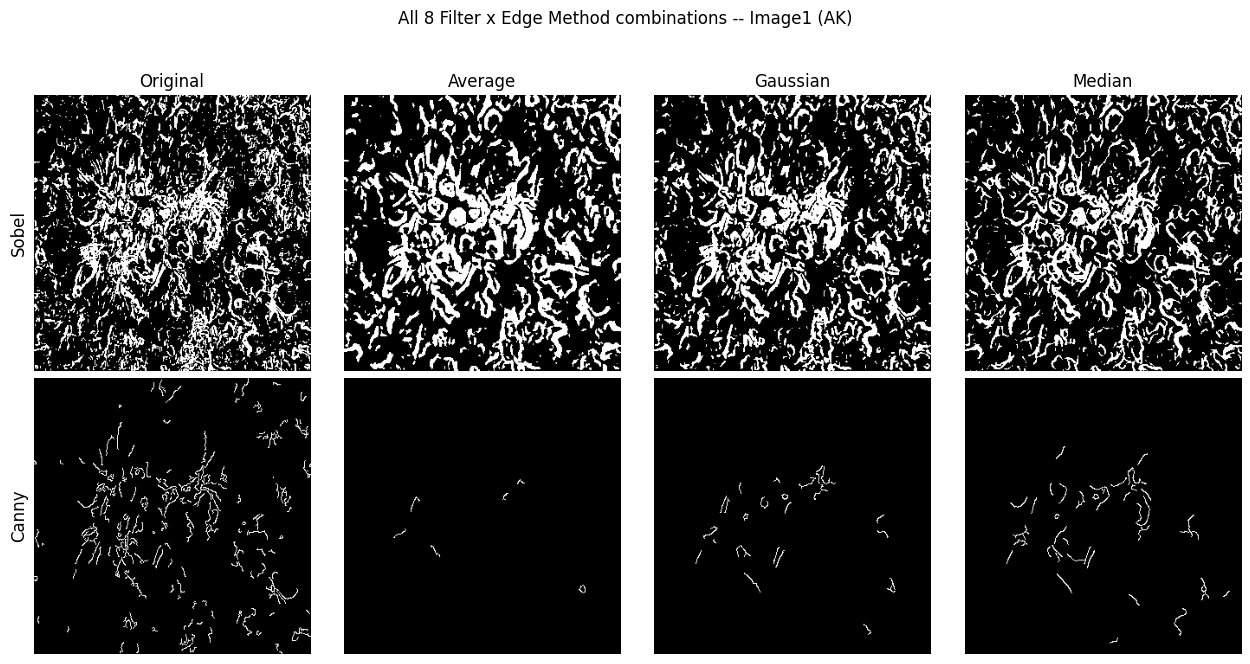

In [23]:
# Bonus visual check: all 8 combinations' edge maps for one representative image.
_demo_lbl = IMAGE_LABELS[0]
fig, axes = plt.subplots(len(EDGE_METHOD_NAMES), len(FILTER_NAMES),
                          figsize=(3.2 * len(FILTER_NAMES), 3.2 * len(EDGE_METHOD_NAMES)))
for col, filter_name in enumerate(FILTER_NAMES):
    for row, edge_name in enumerate(EDGE_METHOD_NAMES):
        edge_map = SWEEP_DETAIL[(_demo_lbl, filter_name, edge_name)]["edge_map"]
        ax = axes[row, col]
        ax.imshow(edge_map, cmap="gray"); _clean_axis(ax)
        if row == 0:
            ax.set_title(filter_name, fontsize=12)
        if col == 0:
            ax.set_ylabel(edge_name, fontsize=12)
fig.suptitle(f"All 8 Filter x Edge Method combinations -- {_demo_lbl} ({IMAGE_CLASS[_demo_lbl]})", y=1.03)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/sweep_demo_{_demo_lbl}.png", dpi=120, bbox_inches="tight")
plt.show()
